<img align="left" style="padding-right:10px;" src="figuras/banner_cd.png">

## 0. Librerias Generales

In [1]:
# Importar librerias
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np

## 1. Obtención y visualización de los datos

In [2]:
#Cargar el archivo datos/german_train_test.txt
df = pd.read_csv('datos/german_test.txt' ,delim_whitespace=True, header=None)

df

/tmp/ipykernel_47626/4294137515.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('datos/german_test.txt' ,delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,16,4,26,1,5,3,4,2,43,...,1,0,0,0,1,0,0,0,1,2
1,4,20,4,35,5,2,1,4,1,44,...,1,0,1,0,0,1,0,0,1,1
2,4,36,4,105,5,5,3,4,4,42,...,0,1,1,0,0,0,0,0,1,1
3,4,15,2,14,5,3,4,2,1,40,...,0,0,1,0,1,0,0,0,1,1
4,4,24,2,13,1,5,3,1,1,36,...,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4,12,2,17,1,4,2,4,1,31,...,0,0,1,0,0,1,0,1,0,1
96,1,30,2,39,1,3,1,4,2,40,...,0,1,1,0,0,1,0,0,0,1
97,4,12,2,8,1,5,3,4,3,38,...,0,0,1,0,0,1,0,0,1,1
98,1,45,2,18,1,3,3,4,4,23,...,0,0,1,0,0,0,0,0,1,2


## 2. Preparación de los datos y funciones

In [3]:
# Preparación de datos
from sklearn.model_selection import train_test_split

In [4]:
## Verificando que no existan valores nulos
df.isnull().any().any()

np.False_

#### División general de los datos


* **X**: Datos sin el diagnostico es decir sin la columna "target"
* **y**: Datos con el diagnostico es decir con la columna "target"

Muestras de entrenamiento y prueba
* **X_train**: este será el grupo de entrenamiento
* **X_test**: este será el  grupo de prueba
* **y_train**: este será el target para el grupo de entrenamiento
* **y_test**: este será el target para el grupo de prueba

In [5]:
#Crear X (Quitar la columna o campo 24)
X = df.loc[ : ,  0:23 ]
X.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,16,4,26,1,5,3,4,2,43,...,1,1,0,0,0,1,0,0,0,1
1,4,20,4,35,5,2,1,4,1,44,...,1,1,0,1,0,0,1,0,0,1
2,4,36,4,105,5,5,3,4,4,42,...,1,0,1,1,0,0,0,0,0,1
3,4,15,2,14,5,3,4,2,1,40,...,1,0,0,1,0,1,0,0,0,1
4,4,24,2,13,1,5,3,1,1,36,...,1,0,0,1,0,0,1,0,0,0


In [6]:
# Crear y (Valor de de la columna "target")
y = df.loc[ :  , 24  ]
y.head()

0    2
1    1
2    1
3    1
4    1
Name: 24, dtype: int64

# 3. Evaluación de Modelos

En un problema de clasificación binaria utilizando machine learning, las métricas de  exactitud (accuracy) , precisión (precision) y exhaustividad (recall) son medidas importantes para evaluar el rendimiento del modelo.

**Exactitud (Accuracy)**:
La exactitud es una medida de la proporción de predicciones correctas que realiza el modelo sobre el total de predicciones realizadas. Se calcula como la proporción entre el número de predicciones correctas y el número total de predicciones. Matemáticamente, se expresa como:
omo positivos.

<img align="left" style="padding-right:5px;" src="figuras/img_accuracy.png">


**Precisión (Precision):**
La precisión es una medida de la proporción de predicciones positivas correctas (verdaderos positivos) respecto al total de predicciones positivas realizadas (verdaderos positivos más falsos positivos). Se enfoca en cuántas de las instancias identificadas como positivas realmente son positivas. Matemáticamente, se calcula como:


<img align="left" style="padding-right:5px;" src="figuras/img_precision.png"> 




**Exhaustividad (Recall):**
La exhaustividad, también conocida como sensibilidad o tasa de verdaderos positivos, mide la proporción de instancias positivas que fueron correctamente identificadas por el modelo respecto al total de instancias positivas en el conjunto de datos (verdaderos positivos más falsos negativos). Matemáticamente, se calcula como:



<img align="left" style="padding-right:5px;" src="figuras/img_recall.png">


In [7]:
# Módulos de evaluación
from sklearn.metrics import accuracy_score
import joblib

### Primer modelo: Clasificador Decision Tree tunned (DT_tunned)

In [8]:
#Cargar el modelo entrenado
modelo_DT_tunned=joblib.load('modelos/modelo_DT_tunned.joblib')

In [9]:
#Realizar predicciones
y_predict_DT_tunned=modelo_DT_tunned.predict(X)

In [10]:
#En caso de error, colocar los siguientes comandos en el CMD:
# pip uninstall scikit-learn
# pip install scikit-learn==1.3.2


In [11]:
#Evaluar el score
modelo_DT_tunned.score(X, y)

0.75

In [12]:
# Importar funciones de métricas de clasificación de scikit-learn
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [13]:
# Realizar predicciones en el conjunto de validación
predictions_DT_tunned = modelo_DT_tunned.predict(X)


In [14]:

# Calcular las métricas de evaluación (accuracy, precision, recall)
accuracy_DT_tunned = accuracy_score(predictions_DT_tunned, y)
precision_DT_tunned = precision_score(predictions_DT_tunned, y)
recall_DT_tunned = recall_score(predictions_DT_tunned, y)

print('accuracy_DT_tunned',accuracy_DT_tunned)
print('precision_DT_tunned',precision_DT_tunned)
print('recall_DT_tunned',recall_DT_tunned)

accuracy_DT_tunned 0.75
precision_DT_tunned 0.9117647058823529
recall_DT_tunned 0.7654320987654321


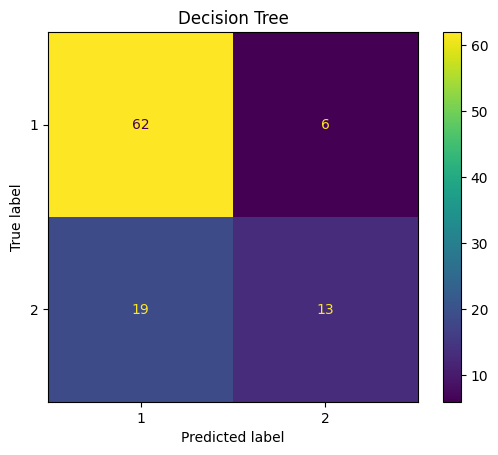

In [15]:
# Matriz de confusión
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions_DT_tunned = modelo_DT_tunned.predict(X)
cm_DT_tunned = confusion_matrix(y, predictions_DT_tunned, labels=modelo_DT_tunned.classes_)
disp_DT_tunned  = ConfusionMatrixDisplay(confusion_matrix=cm_DT_tunned, display_labels=modelo_DT_tunned.classes_)
disp_DT_tunned.plot()
plt.title('Decision Tree')
plt.show()

In [16]:
#Calcular accuracy, precision y  recall


### Segundo modelo: MLP

In [17]:
#Cargar el modelo entrenado
modelo_MLP_tunned=joblib.load('modelos/modelo_MLP_tunned.joblib')

In [18]:
#Realizar predicciones
y_predict_MLP_tunned=modelo_MLP_tunned.predict(X)

In [19]:
#Evaluar el score
modelo_MLP_tunned.score(X, y)

0.77

In [20]:
# Realizar predicciones en el conjunto de validación
predictions_MLP_tunned = modelo_MLP_tunned.predict(X)


In [21]:
# Calcular las métricas de evaluación (accuracy, precision, recall)

accuracy_MLP_tunned = accuracy_score(predictions_MLP_tunned, y)
precision_MLP_tunned = precision_score(predictions_MLP_tunned, y)
recall_MLP_tunned = recall_score(predictions_MLP_tunned, y)

print('accuracy_MLP_tunned',accuracy_MLP_tunned)
print('precision_MLP_tunned',precision_MLP_tunned)
print('recall_MLP_tunned',recall_MLP_tunned)

accuracy_MLP_tunned 0.77
precision_MLP_tunned 0.9117647058823529
recall_MLP_tunned 0.7848101265822784


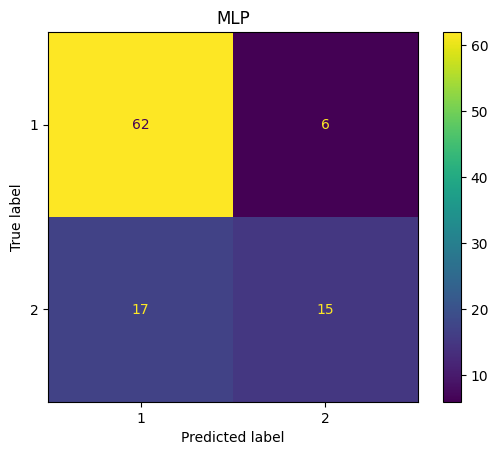

In [22]:
# Matriz de confusión

predictions_MLP_tunned = modelo_MLP_tunned.predict(X)
cm_MLP_tunned = confusion_matrix(y, predictions_MLP_tunned, labels=modelo_MLP_tunned.classes_)
disp_MLP_tunned = ConfusionMatrixDisplay(confusion_matrix=cm_MLP_tunned, display_labels=modelo_MLP_tunned.classes_)
disp_MLP_tunned.plot()
plt.title('MLP')
plt.show()

### Tercer modelo:  --

In [23]:
#Cargar el modelo entrenado
#Cargar el modelo entrenado
modelo_RF_tunned=joblib.load('modelos/modelo_RF_tunned.joblib')


In [24]:
#Realizar predicciones
y_predict_RF_tunned=modelo_RF_tunned.predict(X)


In [25]:
#Evaluar el score
modelo_RF_tunned.score(X, y)


0.79

In [26]:
# Realizar predicciones en el conjunto de validación
predictions_RF_tunned = modelo_RF_tunned.predict(X)


In [27]:
# Calcular las métricas de evaluación (accuracy, precision, recall)

accuracy_RF_tunned = accuracy_score(predictions_RF_tunned, y)
precision_RF_tunned = precision_score(predictions_RF_tunned, y)
recall_RF_tunned = recall_score(predictions_RF_tunned, y)

print('accuracy_RF_tunned',accuracy_RF_tunned)
print('precision_RF_tunned',precision_RF_tunned)
print('recall_RF_tunned',recall_RF_tunned)

accuracy_RF_tunned 0.79
precision_RF_tunned 0.9411764705882353
recall_RF_tunned 0.7901234567901234


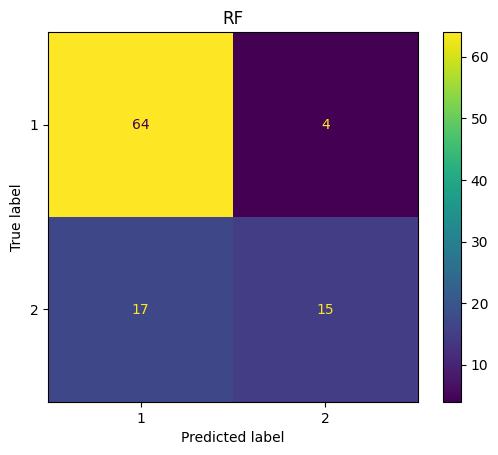

In [28]:
predictions_RF_tunned = modelo_RF_tunned.predict(X)
cm_RF_tunned = confusion_matrix(y, predictions_RF_tunned, labels=modelo_RF_tunned.classes_)
disp_RF_tunned = ConfusionMatrixDisplay(confusion_matrix=cm_RF_tunned, display_labels=modelo_RF_tunned.classes_)
disp_RF_tunned.plot()
plt.title('RF')
plt.show()


## Comparación

| Modelo o clasificador   | Accuracy |  Precision | Recall | 
|---|---|---|---| 
|   DT Tunned | 0.  |  0.    |   0.       |   
|   MLP  Tunned| 0.   |  0.   |   0.     |  
|   NEW  Tunned| 0  |  0  |  0    |  


## Guardar los datos de predicción

In [30]:
# Cargar el modelo
modelo = joblib.load("modelos/modelo_RF_tunned.joblib")

# Hacer las predicciones
y_pred = modelo.predict(X)

# Guardar las predicciones en un archivo CSV
pd.DataFrame(y_pred, columns=["Prediccion"]).to_csv("predicciones_JoseAque.csv", index=False)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.
